In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [2]:
pTrue = 0.1

In [3]:
f = open("C:/Users/koich/Desktop/Code/QAEErrorVsNShotNGrover/output/20230824_FixedGroverIQAE/results_FixedGroverIQAE_pTrue01_epsilon0001_alphaTot005_ratio2.dat","rb")
results = pickle.load(f)

In [4]:
results[0]

{'Estimate': 0.10024942869540196,
 'TotalOracleCalls': 100805,
 'nGrover': [0, 1, 2, 4, 8, 16, 32, 64, 128],
 'nShots': [176, 22579, 525, 48, 107, 179, 33, 93, 31],
 'n1s': [15, 15155, 525, 2, 62, 147, 25, 39, 25],
 'thetaIntervals': [[0, 1.5707963267948966],
  [0.11602520666922374, 0.5229851571696382],
  [0.31416413871480486, 0.3258970783536433],
  [0.3141592653589793, 0.3490491886441497],
  [0.27756175925765714, 0.3486650069088565],
  [0.3048518306553955, 0.33295634241670763],
  [0.31419412410068837, 0.32514219995648974],
  [0.31662380147856073, 0.328698933321871],
  [0.32025255080137394, 0.32390948707958045],
  [0.32050446421272016, 0.32346532806233247]],
 'ampSqIntervals': [[0, 1],
  [0.013401549781558145, 0.2494687792497074],
  [0.0954943673184235, 0.10250164070663637],
  [0.09549150281252627, 0.11696706868369043],
  [0.07508232673374474, 0.11672024432387888],
  [0.09009112767707349, 0.10682336152672356],
  [0.09551199324986208, 0.10204417430234901],
  [0.09694502884083418, 0.1042

In [5]:
errors = [r["Estimate"] - pTrue for r in results]

In [6]:
np.mean(errors)

2.2250504109928736e-05

In [7]:
nGroverLastVals, countNGroverLast = np.unique([r["nGrover"][-1] for r in results], return_counts=True)
print(nGroverLastVals)
print(countNGroverLast)

[ 64 128]
[ 45 955]


In [8]:
nShotsLast = np.unique([r["nShots"][-1] for r in results], return_counts=True)
nShotsLastVals, countNShotsLast = np.unique([r["nShots"][-1] for r in results], return_counts=True)
print(nShotsLastVals)
print(countNShotsLast)

[ 25  26  27  28  29  30  31  32  33  34  35  36  37 114 115]
[ 18  60 125 171 208 154 121  67   5  20   3   2   1  14  31]


In [10]:
from IQAEUtil import Bias

In [19]:
finalGroverNum = 128
Bias(pTrue, finalGroverNum, 30)

9.40717756684502e-06

In [17]:
p1Last = [r["n1s"][-1] / r["nShots"][-1] for r in results]

(array([ 51.,  23.,  50., 124., 171., 208., 181., 111.,  60.,  21.]),
 array([0.44444444, 0.49189189, 0.53933934, 0.58678679, 0.63423423,
        0.68168168, 0.72912913, 0.77657658, 0.82402402, 0.87147147,
        0.91891892]),
 <BarContainer object of 10 artists>)

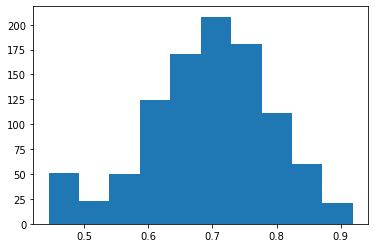

In [18]:
plt.hist(p1Last)

In [22]:
errors_nGroverLast128 = []
for r in results:
    if r["nGrover"][-1] == 128:
        errors_nGroverLast128.append(r["Estimate"] - pTrue)

In [23]:
np.mean(errors_nGroverLast128)

3.346291136534818e-06

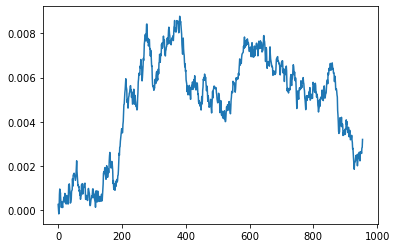

In [24]:
ax = plt.gca()
plt.plot(np.array(errors_nGroverLast128).cumsum())
plt.show()

In [26]:
print(np.sum(errors_nGroverLast128))
print(np.std(errors_nGroverLast128) * np.sqrt(len(errors_nGroverLast128)))

0.0031957080353907513
0.006799028248676289
